# EDA da Unidade Movel Caju

Este notebook será usado para a análise exploratória individual da **Unidade Movel Caju**. Nesta primeira etapa, vamos montar a **auditoria da base**, que serve para verificar se a série da Unidade Movel é confiável e em quais períodos ela apresenta melhor ou pior qualidade.


## Carregamento da base

Primeiro, carregamos a base consolidada de qualidade do ar e isolamos apenas os registros da Unidade Movel de Caju. Como o nome da Unidade Movel pode vir com problema de codificação, fazemos uma normalização simples para garantir um filtro robusto.


In [1]:
import pandas as pd
import unicodedata
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_caju = df_air_quality[df_air_quality["Nome"] == "UNIDADE MOVEL CAJU"].copy()

print("Dimensoes da base da Unidade Movel Caju:", df_caju.shape)
display(df_caju.head())

Dimensoes da base da Unidade Movel Caju: (12656, 15)


,data,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
88004,2013-02-21 11:30:00,UNIDADE MOVEL CAJU,0.0,34.05,46.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.875845,-43.222494
88007,2013-02-21 12:30:00,UNIDADE MOVEL CAJU,0.0,35.23,39.25,22.11,NaN,0.0,NaN,NaN,0.0,NaN,NaN,-22.875845,-43.222494
88022,2013-02-21 13:30:00,UNIDADE MOVEL CAJU,0.0,36.37,36.43,27.97,NaN,0.0,NaN,NaN,0.0,NaN,NaN,-22.875845,-43.222494
88036,2013-02-21 14:30:00,UNIDADE MOVEL CAJU,0.0,37.92,31.60,31.52,NaN,0.0,NaN,NaN,0.0,NaN,NaN,-22.875845,-43.222494
88037,2013-02-21 15:30:00,UNIDADE MOVEL CAJU,0.0,37.88,35.57,33.75,NaN,0.0,NaN,NaN,0.0,NaN,11.0,-22.875845,-43.222494


## Auditoria da base


### 1. Período coberto e frequência observada

Nesta célula verificamos o intervalo temporal da base, o número de timestamps únicos, o intervalo mais frequente entre observações e a distribuição do minuto da medição. Isso ajuda a confirmar se a série realmente se comporta como uma série **horária**.


In [3]:
df_caju["data"] = pd.to_datetime(df_caju["data"], errors="coerce")

timestamps_unicos = df_caju["data"].drop_duplicates().sort_values()
intervalos = timestamps_unicos.diff().dropna()

intervalo_modal = intervalos.mode().iloc[0] if not intervalos.empty else pd.Timedelta(hours=1)

resumo_periodo = pd.DataFrame(
    {
        "metrica": [
            "primeira_medicao",
            "ultima_medicao",
            "n_linhas",
            "anos_cobertos",
        ],
        "valor": [
            timestamps_unicos.min(),
            timestamps_unicos.max(),
            len(df_caju),
            df_caju["data"].dt.year.nunique(),
        ],
    }
)

display(resumo_periodo)

,metrica,valor
0,primeira_medicao,2013-02-21 11:30:00
1,ultima_medicao,2016-01-13 13:30:00
2,n_linhas,12656
3,anos_cobertos,4


### 2. Datas faltantes e cobertura temporal

Agora montamos um calendário esperado usando o intervalo modal da série e verificamos:

- quantos timestamps estão faltando no período total;
- quais são alguns exemplos de lacunas;
- como a **completude** se comporta por ano e por mês.

Esse bloco é importante porque, mesmo que a Unidade Movel tenha um período longo, ela pode ter meses com baixa confiabilidade.


In [4]:
indice_esperado = pd.date_range(timestamps_unicos.min(), timestamps_unicos.max(), freq=intervalo_modal)
timestamps_faltantes = indice_esperado.difference(timestamps_unicos)

print("Quantidade de timestamps esperados:", len(indice_esperado))
print("Quantidade de timestamps observados:", len(timestamps_unicos))
print("Quantidade de timestamps faltantes:", len(timestamps_faltantes))

if len(timestamps_faltantes) > 0:
    display(pd.DataFrame({"data_faltante": timestamps_faltantes[:20]}))
else:
    print("Nao foram encontrados timestamps faltantes na serie.")

df_cobertura = pd.DataFrame({"data": indice_esperado})
df_cobertura["observada"] = df_cobertura["data"].isin(timestamps_unicos).astype(int)
df_cobertura["ano"] = df_cobertura["data"].dt.year
df_cobertura["mes"] = df_cobertura["data"].dt.month
df_cobertura["ano_mes"] = df_cobertura["data"].dt.to_period("M").astype(str)

cobertura_anual = (
    df_cobertura.groupby("ano", as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_anual["faltantes"] = cobertura_anual["medicoes_esperadas"] - cobertura_anual["medicoes_observadas"]
cobertura_anual["completude_pct"] = (100 * cobertura_anual["medicoes_observadas"] / cobertura_anual["medicoes_esperadas"]).round(2)

cobertura_mensal = (
    df_cobertura.groupby(["ano_mes", "ano", "mes"], as_index=False)
    .agg(
        medicoes_esperadas=("observada", "size"),
        medicoes_observadas=("observada", "sum"),
    )
)
cobertura_mensal["faltantes"] = cobertura_mensal["medicoes_esperadas"] - cobertura_mensal["medicoes_observadas"]
cobertura_mensal["completude_pct"] = (100 * cobertura_mensal["medicoes_observadas"] / cobertura_mensal["medicoes_esperadas"]).round(2)

display(cobertura_anual)
display(cobertura_mensal.sort_values(["completude_pct", "ano_mes"]).head(15))

Quantidade de timestamps esperados: 25347
Quantidade de timestamps observados: 12656
Quantidade de timestamps faltantes: 12691


,data_faltante
0,2013-03-04 10:30:00
1,2013-03-04 11:30:00
2,2013-03-04 12:30:00
3,2013-03-04 13:30:00
4,2013-03-06 00:30:00
5,2013-03-06 01:30:00
6,2013-03-06 02:30:00
7,2013-03-06 03:30:00
8,2013-03-06 04:30:00
9,2013-03-06 05:30:00


,ano,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
0,2013,7525,4176,3349,55.50
1,2014,8760,2500,6260,28.54
2,2015,8760,5678,3082,64.82
3,2016,302,302,0,100.00


,ano_mes,ano,mes,medicoes_esperadas,medicoes_observadas,faltantes,completude_pct
7,2013-09,2013,9,720,0,720,0.0
8,2013-10,2013,10,744,0,744,0.0
9,2013-11,2013,11,720,0,720,0.0
10,2013-12,2013,12,744,0,744,0.0
11,2014-01,2014,1,744,0,744,0.0
12,2014-02,2014,2,672,0,672,0.0
13,2014-03,2014,3,744,0,744,0.0
14,2014-04,2014,4,720,0,720,0.0
15,2014-05,2014,5,744,0,744,0.0
16,2014-06,2014,6,720,0,720,0.0


### 3. Colunas totalmente vazias e percentual de missing por variável

Nesta etapa medimos a completude de cada coluna. Isso ajuda a responder, por exemplo, se algum poluente praticamente não existe na série, se uma variável tem muitos vazios em certos períodos ou se alguma coluna está completamente inútil para análise.


In [5]:
missing_por_variavel = pd.DataFrame(
    {
        "coluna": df_caju.columns,
        "n_missing": df_caju.isna().sum().values,
        "missing_pct": (100 * df_caju.isna().mean()).round(2).values,
    }
)

missing_por_variavel = missing_por_variavel.sort_values(["missing_pct", "coluna"], ascending=[False, True]).reset_index(drop=True)
colunas_totalmente_vazias = missing_por_variavel[missing_por_variavel["missing_pct"] == 100].copy()

print("Quantidade de colunas totalmente vazias:", len(colunas_totalmente_vazias))

if len(colunas_totalmente_vazias) > 0:
    display(colunas_totalmente_vazias)
else:
    print("Nenhuma coluna esta completamente vazia.")

display(missing_por_variavel)

Quantidade de colunas totalmente vazias: 4


,coluna,n_missing,missing_pct
0,no,12656,100.0
1,no2,12656,100.0
2,nox,12656,100.0
3,pm10,12656,100.0


,coluna,n_missing,missing_pct
0,no,12656,100.00
1,no2,12656,100.00
2,nox,12656,100.00
3,pm10,12656,100.00
4,co,1244,9.83
5,so2,1104,8.72
6,ur,351,2.77
7,o3,333,2.63
8,pm2_5,333,2.63
9,chuva,165,1.30


## Caracterização inicial das variáveis

Nesta etapa, o objetivo é entender o **nível típico**, a **dispersão** e o **formato da distribuição** de cada poluente e variável meteorológica da Unidade Movel.

Para isso, vamos olhar:

- média, mediana, desvio padrão, quartis, mínimo, máximo e assimetria;
- histogramas das distribuições;
- distribuição de **nulos por dia** para cada variável.

Esse último ponto é especialmente importante porque ele ajuda a identificar quais variáveis têm dias com poucas horas faltantes, o que pode apoiar um tratamento futuro de imputação em dias com, por exemplo, menos de 4 horas ausentes.


### Preparando as variáveis da seção

Primeiro, separamos explicitamente as variáveis meteorológicas e os poluentes, padronizamos os tipos numéricos e criamos uma coluna de `data_dia` para apoiar a análise de nulos diários.


In [6]:
variaveis_meteorologicas = ["chuva", "temp", "ur"]
poluentes = ["so2", "no2", "co", "no", "nox", "o3", "pm10", "pm2_5"]
variaveis_analise = [coluna for coluna in variaveis_meteorologicas + poluentes if coluna in df_caju.columns]

df_caju_carac = df_caju.copy()
df_caju_carac["data"] = pd.to_datetime(df_caju_carac["data"], errors="coerce")
df_caju_carac["data_dia"] = df_caju_carac["data"].dt.normalize()

for coluna in variaveis_analise:
    df_caju_carac[coluna] = pd.to_numeric(df_caju_carac[coluna], errors="coerce")

display(pd.DataFrame({
    "variavel": variaveis_analise,
    "tipo": ["meteorologica" if v in variaveis_meteorologicas else "poluente" for v in variaveis_analise],
}))

,variavel,tipo
0,chuva,meteorologica
1,temp,meteorologica
2,ur,meteorologica
3,so2,poluente
4,no2,poluente
5,co,poluente
6,no,poluente
7,nox,poluente
8,o3,poluente
9,pm10,poluente


### Estatísticas descritivas por variável

Aqui resumimos cada variável com medidas de posição, dispersão e forma. A comparação entre **média** e **mediana** ajuda a perceber assimetria; o **desvio padrão** e os **quartis** mostram a variabilidade; e a **assimetria** ajuda a identificar concentração de valores baixos com picos mais raros para cima.


In [7]:
estatisticas_variaveis = []

for variavel in variaveis_analise:
    serie = df_caju_carac[variavel]
    estatisticas_variaveis.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "n_validos": int(serie.notna().sum()),
            "n_missing": int(serie.isna().sum()),
            "missing_pct": round(100 * serie.isna().mean(), 2),
            "media": round(serie.mean(), 2),
            "mediana": round(serie.median(), 2),
            "desvio_padrao": round(serie.std(), 2),
            "q1": round(serie.quantile(0.25), 2),
            "q3": round(serie.quantile(0.75), 2),
            "min": round(serie.min(), 2),
            "max": round(serie.max(), 2),
            "assimetria": round(serie.skew(), 2),
        }
    )

estatisticas_variaveis = pd.DataFrame(estatisticas_variaveis)
estatisticas_variaveis = estatisticas_variaveis.sort_values(["tipo", "variavel"]).reset_index(drop=True)

display(estatisticas_variaveis)

c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,variavel,tipo,n_validos,n_missing,missing_pct,media,mediana,desvio_padrao,q1,q3,min,max,assimetria
0,chuva,meteorologica,12491,165,1.30,0.09,0.00,0.97,0.00,0.00,0.00,61.00,31.21
1,temp,meteorologica,12501,155,1.22,25.96,25.63,4.15,23.10,28.52,14.50,40.42,0.35
2,ur,meteorologica,12305,351,2.77,69.90,71.28,15.01,59.68,81.27,18.13,99.80,-0.38
3,co,poluente,11412,1244,9.83,0.26,0.18,0.36,0.07,0.33,0.00,16.64,13.82
4,no,poluente,0,12656,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,no2,poluente,0,12656,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,nox,poluente,0,12656,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,o3,poluente,12323,333,2.63,18.12,9.58,23.26,2.07,25.02,0.00,216.56,2.30
8,pm10,poluente,0,12656,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,pm2_5,poluente,12323,333,2.63,20.55,16.00,17.47,10.00,27.00,0.00,476.00,4.80


### Nulos por dia por variável

Agora traduzimos os missings para uma lógica diária. Em vez de olhar apenas o percentual total de nulos, calculamos quantas **horas faltaram em cada dia** para cada variável.

Isso permite responder perguntas como:

- quantos dias estão completos;
- quantos dias têm apenas `1`, `2` ou `3` horários faltantes;
- quantos dias já estão em um nível de incompletude mais severo.

Essa leitura é muito útil para decidir, no futuro, se vale imputar dias com menos de 4 horas ausentes.


In [8]:
timestamps_carac = df_caju_carac["data"].dropna().drop_duplicates().sort_values()
intervalos_carac = timestamps_carac.diff().dropna()
intervalo_modal_carac = intervalos_carac.mode().iloc[0] if not intervalos_carac.empty else pd.Timedelta(hours=1)

# Convertendo o intervalo modal para quantidade esperada de medicoes por dia.
medicoes_esperadas_por_dia = int(pd.Timedelta(days=1) / intervalo_modal_carac)
indice_dias = pd.date_range(df_caju_carac["data_dia"].min(), df_caju_carac["data_dia"].max(), freq="D")

distribuicoes_missing_diario = {}
resumo_missing_diario = []

for variavel in variaveis_analise:
    validas_por_dia = df_caju_carac.groupby("data_dia")[variavel].apply(lambda s: s.notna().sum())
    validas_por_dia = validas_por_dia.reindex(indice_dias, fill_value=0)

    faltantes_por_dia = medicoes_esperadas_por_dia - validas_por_dia
    faltantes_por_dia = faltantes_por_dia.clip(lower=0)

    distribuicoes_missing_diario[variavel] = faltantes_por_dia

    resumo_missing_diario.append(
        {
            "variavel": variavel,
            "tipo": "meteorologica" if variavel in variaveis_meteorologicas else "poluente",
            "medicoes_esperadas_por_dia": medicoes_esperadas_por_dia,
            "dias_no_periodo": len(indice_dias),
            "dias_sem_falta": int((faltantes_por_dia == 0).sum()),
            "dias_com_1_a_4_faltantes": int(((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).sum()),
            "pct_dias_com_ate_4_faltantes": round(100 * ((faltantes_por_dia >= 1) & (faltantes_por_dia <= 4)).mean(), 2),
            "dias_com_5_ou_mais_faltantes": int((faltantes_por_dia >= 5).sum()),
        }
    )

resumo_missing_diario = pd.DataFrame(resumo_missing_diario)
resumo_missing_diario = resumo_missing_diario.sort_values(["tipo", "variavel"]).reset_index(drop=True)

print("Intervalo modal considerado:", intervalo_modal_carac)
print("Medicoes esperadas por dia:", medicoes_esperadas_por_dia)
display(resumo_missing_diario)

Intervalo modal considerado: 0 days 01:00:00
Medicoes esperadas por dia: 24


,variavel,tipo,medicoes_esperadas_por_dia,dias_no_periodo,dias_sem_falta,dias_com_1_a_4_faltantes,pct_dias_com_ate_4_faltantes,dias_com_5_ou_mais_faltantes
0,chuva,meteorologica,24,1057,499,11,1.04,547
1,temp,meteorologica,24,1057,486,24,2.27,547
2,ur,meteorologica,24,1057,476,25,2.37,556
3,co,poluente,24,1057,231,225,21.29,601
4,no,poluente,24,1057,0,0,0.00,1057
5,no2,poluente,24,1057,0,0,0.00,1057
6,nox,poluente,24,1057,0,0,0.00,1057
7,o3,poluente,24,1057,440,60,5.68,557
8,pm10,poluente,24,1057,0,0,0.00,1057
9,pm2_5,poluente,24,1057,431,71,6.72,555


### Histogramas e distribuição de nulos por dia

Para cada variável, vamos visualizar dois aspectos ao mesmo tempo:

- `esquerda`: histograma da distribuição dos valores observados;
- `direita`: distribuição da quantidade de horas faltantes por dia.

No gráfico de nulos diários, a linha vermelha marca o limite de **4 horas faltantes**, que pode ser usado depois como critério de imputação.


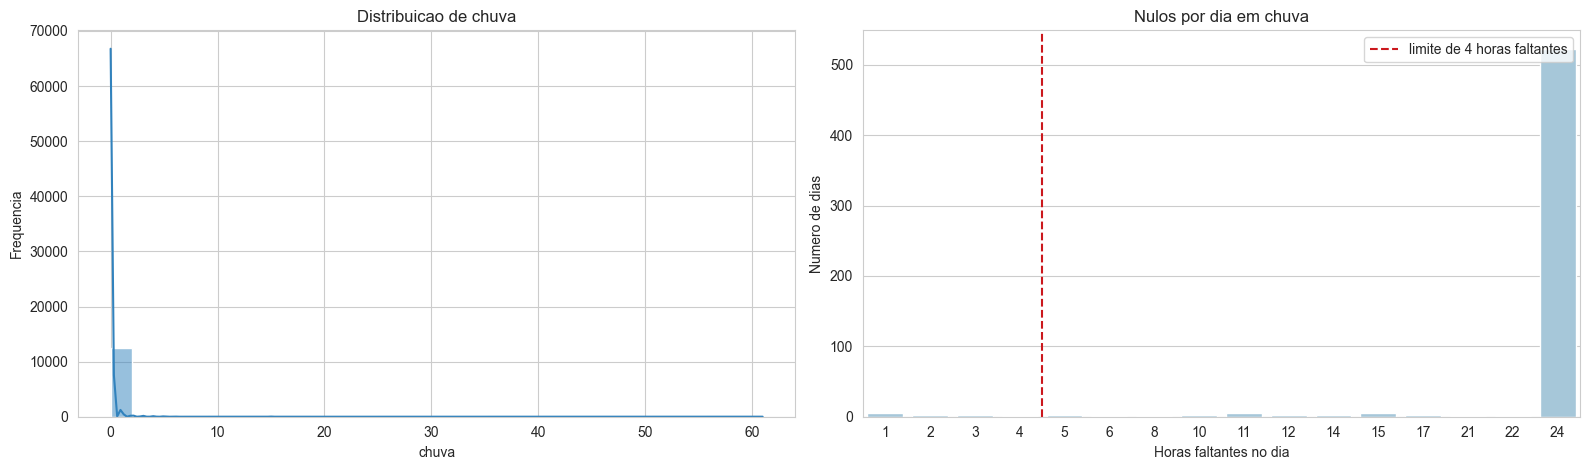

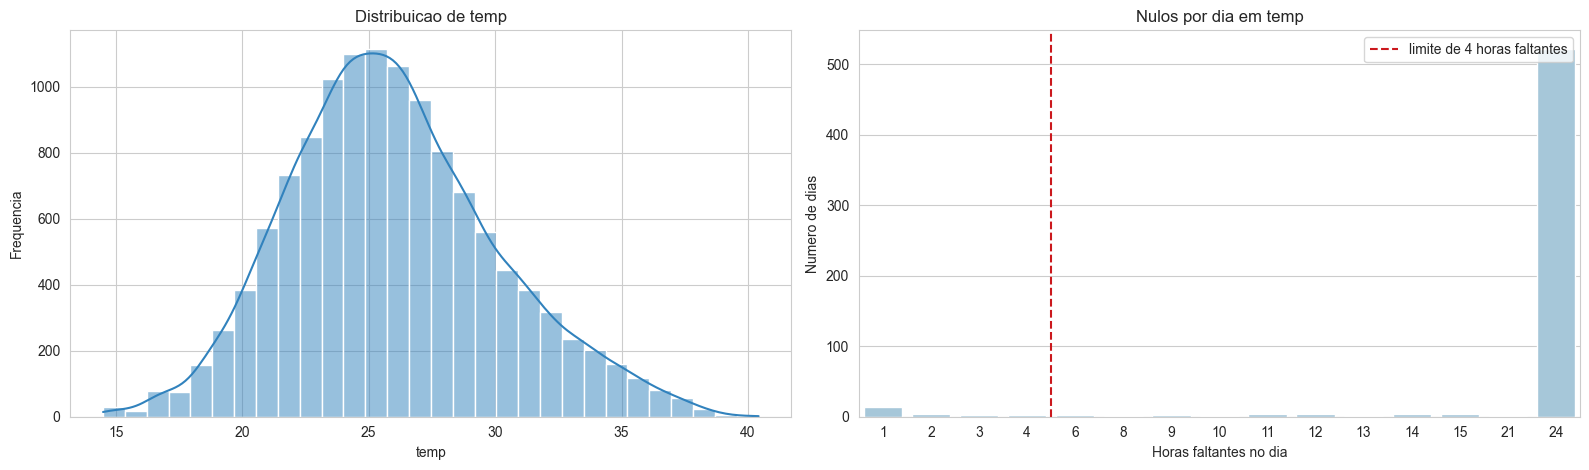

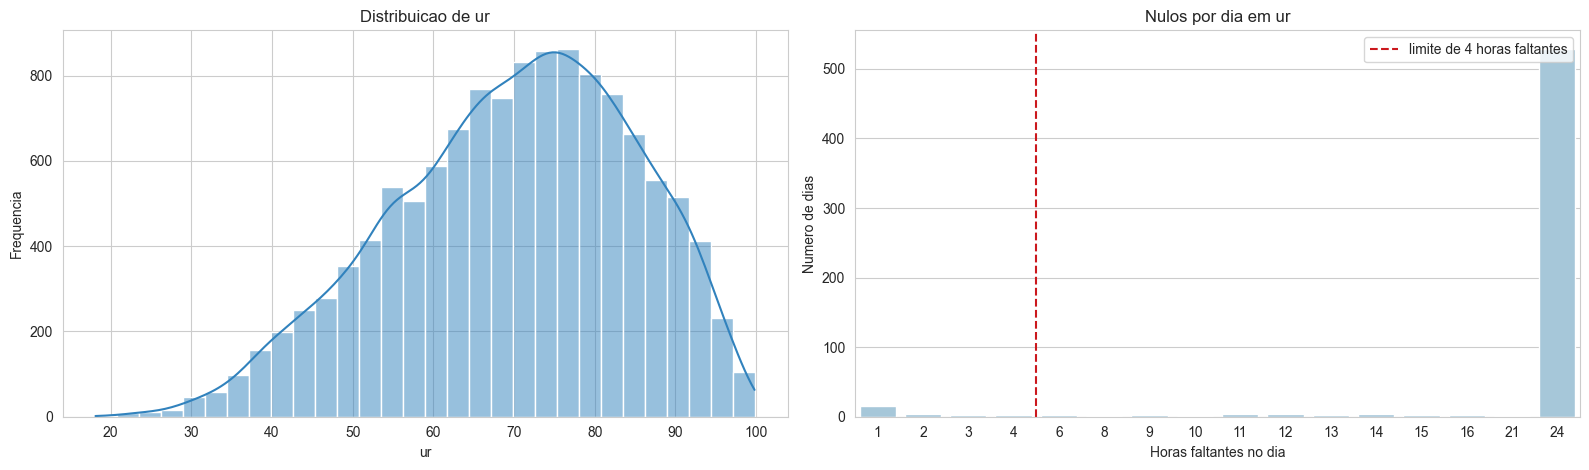

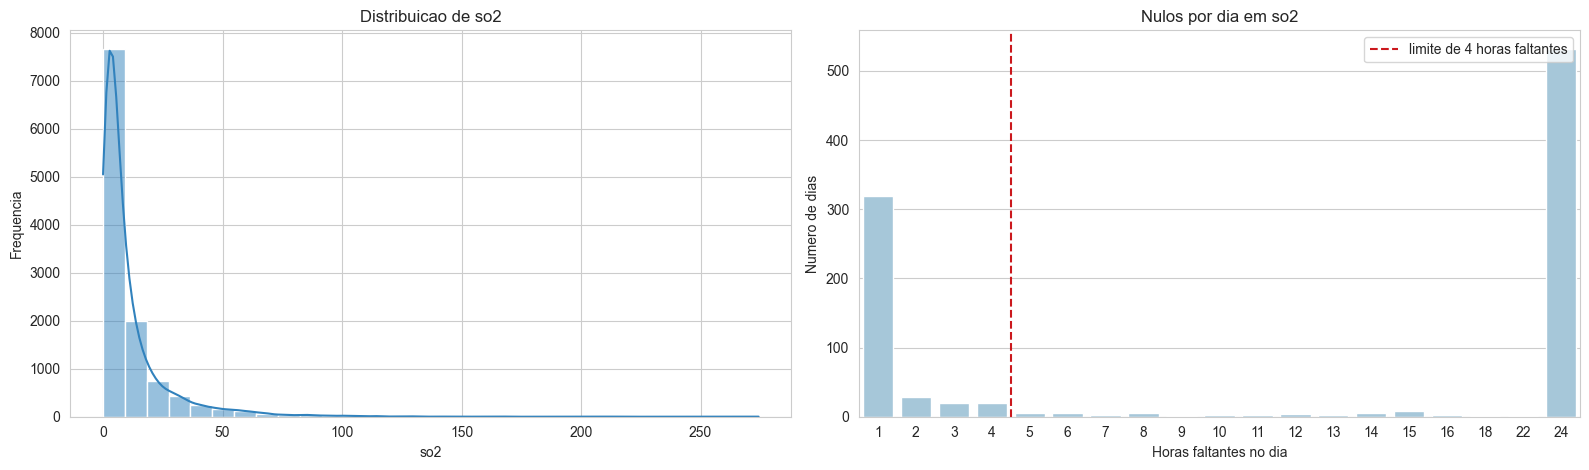

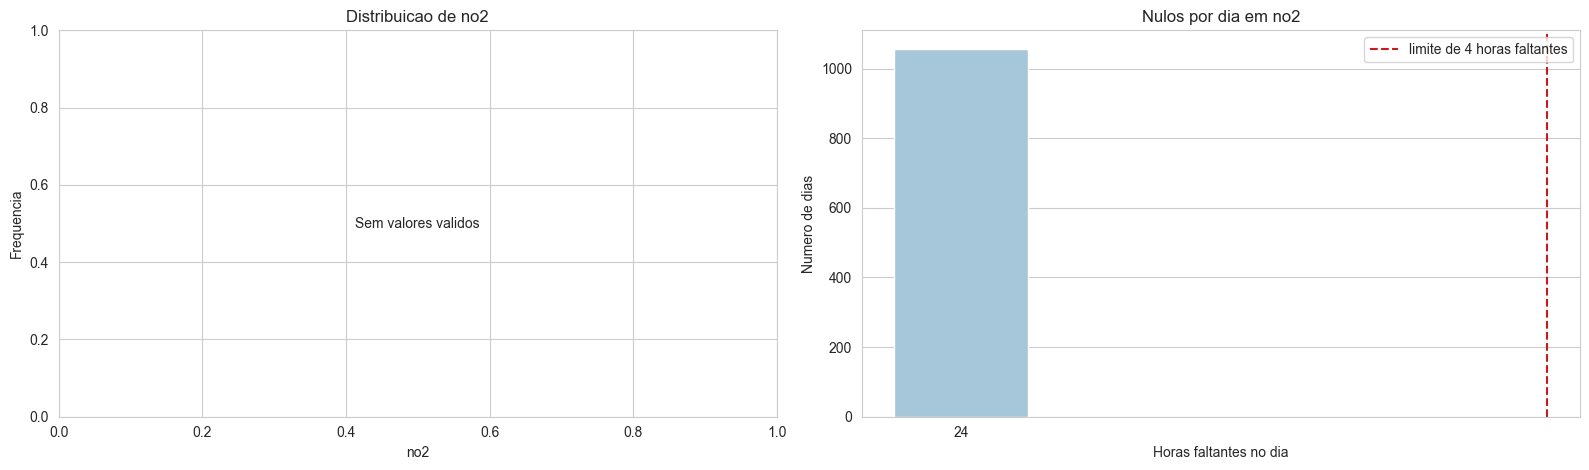

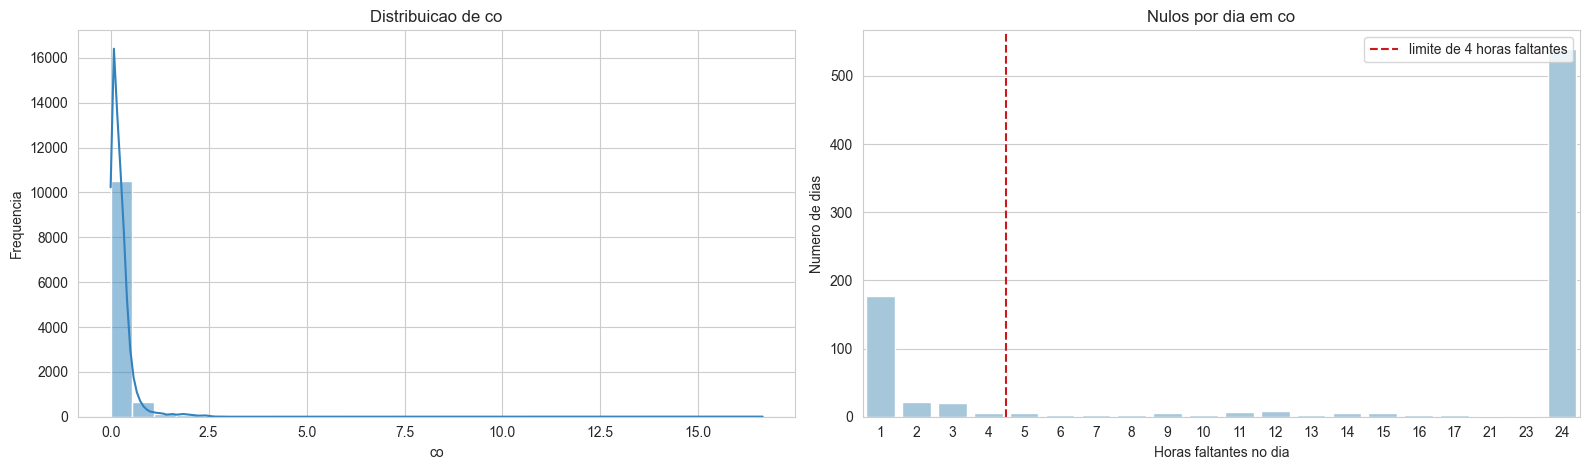

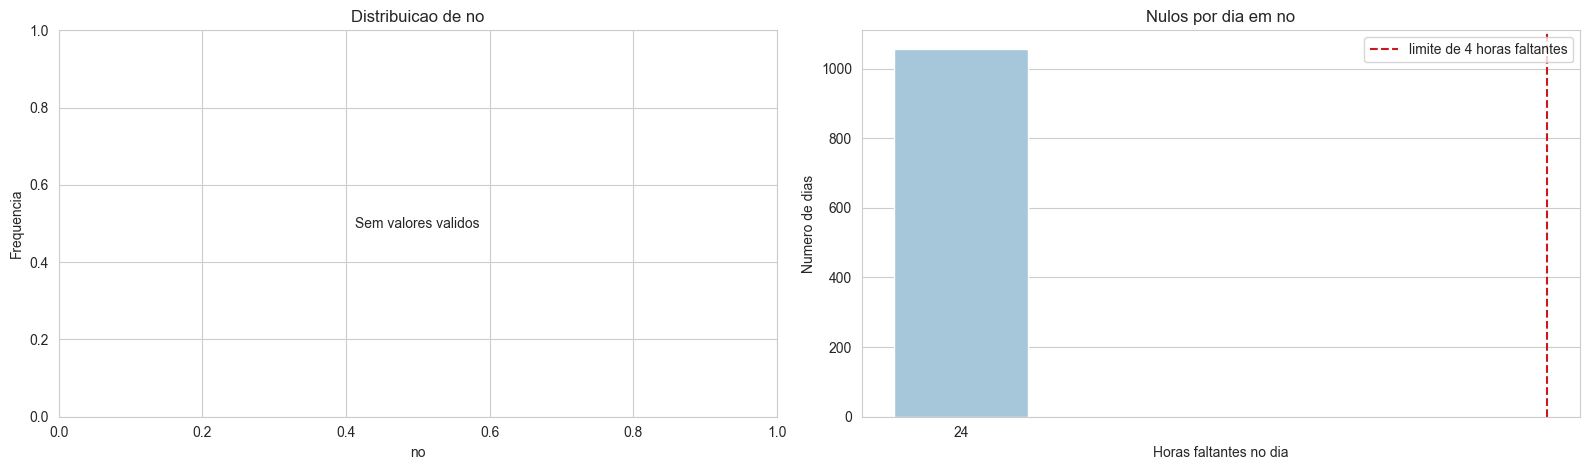

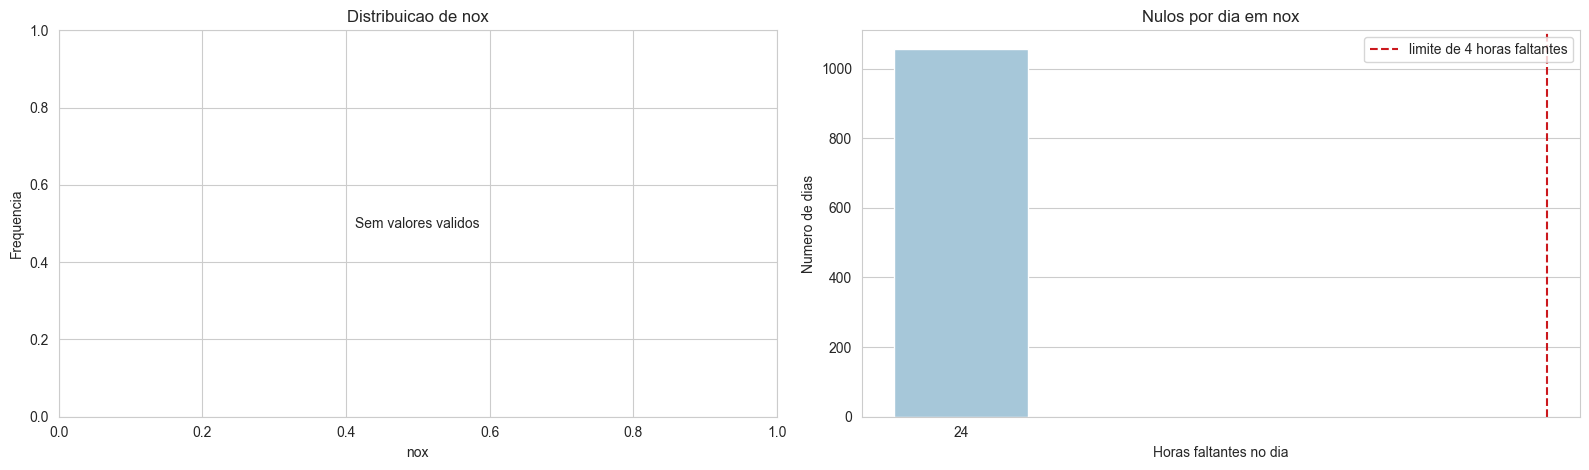

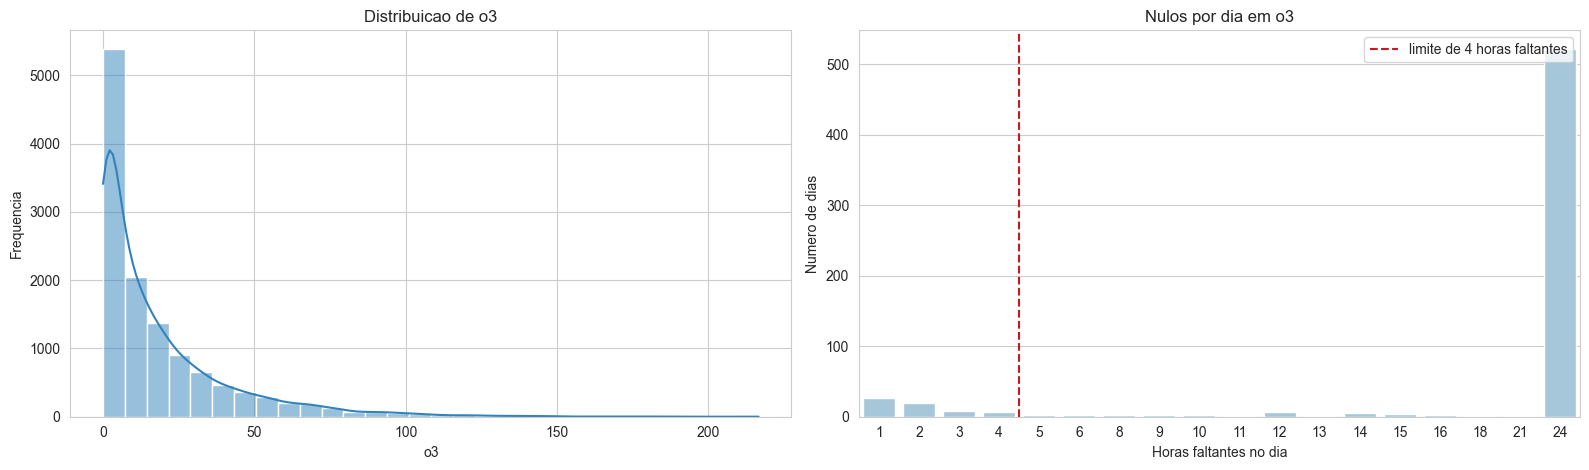

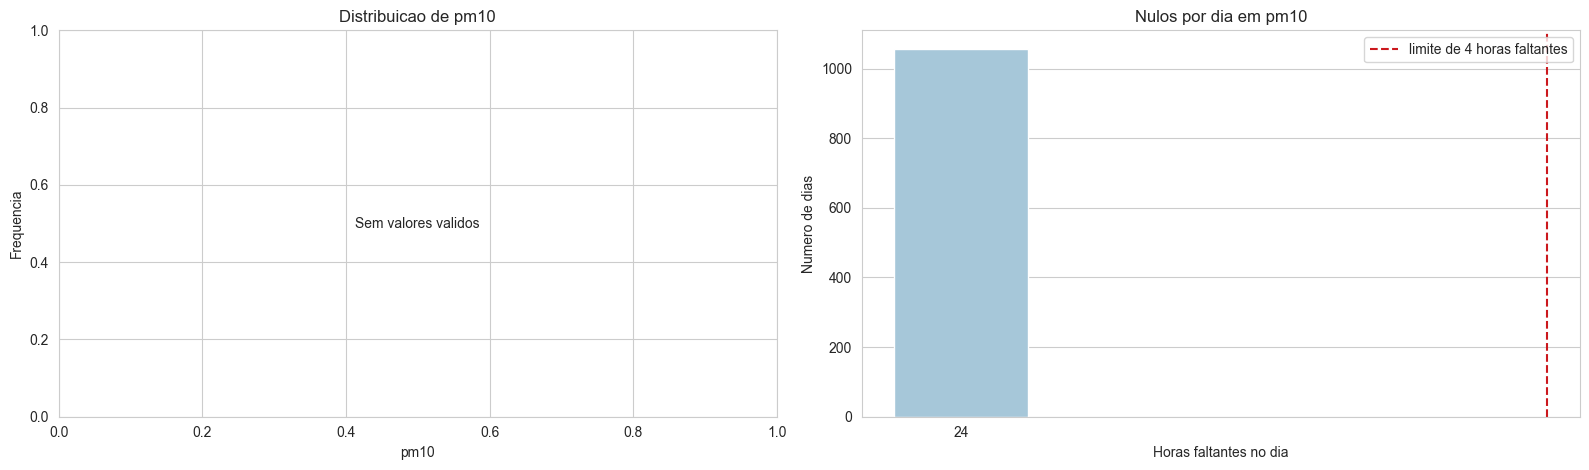

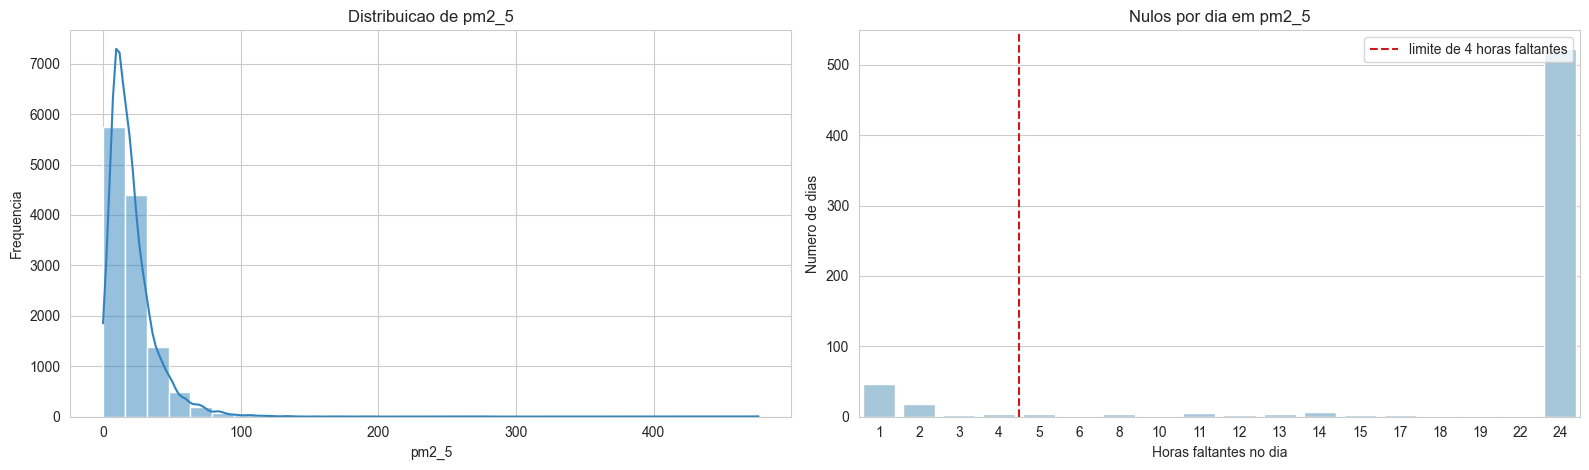

In [9]:
sns.set_style("whitegrid")

for variavel in variaveis_analise:
    serie = df_caju_carac[variavel].dropna()
    faltantes_por_dia = distribuicoes_missing_diario[variavel]
    distribuicao_faltantes = (
        faltantes_por_dia.value_counts()
        .sort_index()
        .rename_axis("horas_faltantes")
        .reset_index(name="n_dias")
    )
    distribuicao_faltantes = distribuicao_faltantes[distribuicao_faltantes["horas_faltantes"] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

    if not serie.empty:
        sns.histplot(serie, bins=30, kde=True, color="#3182bd", ax=axes[0])
    else:
        axes[0].text(0.5, 0.5, "Sem valores validos", ha="center", va="center", transform=axes[0].transAxes)

    axes[0].set_title(f"Distribuicao de {variavel}")
    axes[0].set_xlabel(variavel)
    axes[0].set_ylabel("Frequencia")

    if not distribuicao_faltantes.empty:
        sns.barplot(data=distribuicao_faltantes, x="horas_faltantes", y="n_dias", color="#9ecae1", ax=axes[1])
        axes[1].axvline(3.5, color="#cb181d", linestyle="--", linewidth=1.5, label="limite de 4 horas faltantes")
        axes[1].legend(loc="upper right")
    else:
        axes[1].text(0.5, 0.5, "Sem dias com horas faltantes", ha="center", va="center", transform=axes[1].transAxes)

    axes[1].set_title(f"Nulos por dia em {variavel}")
    axes[1].set_xlabel("Horas faltantes no dia")
    axes[1].set_ylabel("Numero de dias")

    plt.tight_layout()
    plt.show()

## Resumo interpretativo dos resultados

Os resultados indicam que a Unidade Movel Caju tem uma base **analiticamente util, mas fragil do ponto de vista temporal e operacional**, com perfil tipico de monitoramento de campanha. A serie cobre o periodo de `2013-02-21 11:30` a `2016-01-13 13:30`, sem duplicatas de horario, mas com um calendario bastante irregular: ha `12691` timestamps faltantes em `25347` esperados. Alem disso, a unidade apresenta `3` pares distintos de coordenadas ao longo do periodo, o que sugere mudancas de posicionamento ou de configuracao operacional. Assim, nesta base, a confiabilidade precisa ser avaliada nao apenas pela completude das variaveis, mas tambem pela continuidade temporal e pela estabilidade espacial da campanha.

A leitura de missing por variavel mostra uma divisao clara entre series estruturalmente ausentes e series efetivamente utilizaveis. `no`, `no2`, `nox` e `pm10` estao estruturalmente indisponiveis (`100%` de nulos) e, neste recorte, nao devem ser tratados como variaveis analisaveis. Entre as variaveis disponiveis, `co` (`9,8%`) e `so2` (`8,7%`) sao as mais sensiveis em completude, enquanto `ur` (`2,8%`), `o3` (`2,6%`), `pm2_5` (`2,6%`), `chuva` (`1,3%`) e `temp` (`1,2%`) aparecem em condicao melhor. Em termos praticos, a unidade preserva um conjunto ambiental interessante, mas a irregularidade da linha do tempo limita comparacoes diretas ao longo de toda a campanha.

As distribuicoes reforcam um comportamento heterogeneo, com predominio de valores usuais e alguns episodios elevados. `chuva` segue muito concentrada em zero e altamente assimetrica, enquanto `temp` e `ur` apresentam comportamento mais estavel. Entre os poluentes disponiveis, `co`, `o3`, `pm2_5` e `so2` mostram **assimetria a direita**, o que indica presenca de picos ocasionais. Em Caju, chamam atencao os niveis centrais e os extremos de `pm2_5` e `so2`, alem de picos importantes em `o3` e `co`. Isso sugere uma unidade potencialmente interessante para estudar particulado fino, oxidacao atmosferica e enxofre em um ambiente urbano-industrial, desde que a interpretacao respeite a descontinuidade da serie.

A distribuicao diaria de nulos ajuda a separar lacunas curtas de perdas mais severas dentro dos dias observados. `so2` se destaca por concentrar muitos dias com apenas `1` a `4` horas faltantes, o que o torna um bom candidato a preenchimento pontual, mesmo convivendo com parte de dias mais incompletos. `co` tambem mostra um volume importante de lacunas curtas, enquanto `o3` e `pm2_5` aparecem em situacao intermediaria favoravel. `temp`, `ur` e `chuva` sao as variaveis mais confiaveis no nivel diario. Ainda assim, o ponto central da unidade nao e apenas a falta dentro dos dias monitorados, mas sim a presenca de muitos intervalos inteiros sem observacao ao longo do calendario.

Em sintese, a Unidade Movel Caju parece **util com cautela como base exploratoria de campanha**, porque combina um conjunto analitico razoavel com uma linha do tempo muito descontínua e mudancas de coordenadas. `no`, `no2`, `nox` e `pm10` devem ser excluidos ou tratados como indisponiveis, `co` e `so2` pedem controle adicional de completude, e `chuva`, `temp`, `ur`, `o3` e `pm2_5` formam o nucleo mais promissor da unidade. Isso deixa claro que, em Caju, a capacidade analitica existe, mas a comparabilidade temporal e espacial da serie precisa ser tratada com cuidado antes de qualquer analise mais forte ou integracao com outras estacoes.
